# Tutorial 03 — Network Constraints: DC Power Flow and DC-OPF

> **What changes when electricity must actually move through a network?**

## Where we are

```text
ED → UC → >> DC-OPF << → AC-OPF → SOCP → multi-period → uncertainty
                        → Benders → column generation → capstone
           ^
           YOU ARE HERE
```

## Learning objectives

1. State the four DC approximations **explicitly**, and say what each discards;
2. derive $P_{ij} = B_{ij}(\theta_i - \theta_j)$ and nodal balance;
3. build a DC-OPF in Pyomo and find where congestion binds;
4. decompose a **locational marginal price** into energy and congestion;
5. derive **PTDFs** and show the angle and PTDF formulations agree;
6. explain why one price became three.

## The claim this notebook tests

> "Linear means inaccurate."

It is a blanket statement and blanket statements about model classes are
usually wrong. DC-OPF is linear *and* an approximation — two separate facts,
and Tutorial 05 shows the second one has a precise meaning that "inaccurate"
does not capture.

In [1]:
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import pyomo.environ as pyo

from psopt_course.config import fast_mode, set_seed
from psopt_course.networks import three_bus_system
from psopt_course.plotting import COLORS, use_course_style
from psopt_course.solvers import solve

use_course_style()
set_seed()
print(f"reduced (fast) configuration: {fast_mode()}")

reduced (fast) configuration: False


## 1. The system

Three buses, three lines, three generators, three loads. The cheap generation
is at bus 0 and the big load is at bus 2 — so power has to travel, and one
line is deliberately too thin.

,bus,p_min,p_max,c1 [EUR/MWh],c2 [EUR/MWh^2],start [EUR]
name,,,,,,
G1_cheap,0,0.0,150.0,20.0,0.0,800.0
G2_mid,1,0.0,100.0,45.0,0.0,300.0
G3_peaker,2,0.0,80.0,90.0,0.0,100.0


,from,to,x [pu],B [MW/rad],capacity [MW]
name,,,,,
L_0_1,0,1,0.20,500.0,100.0
L_1_2,1,2,0.25,400.0,100.0
L_0_2,0,2,0.10,1000.0,40.0


demand by bus: {0: 20.0, 1: 60.0, 2: 130.0},  total 210 MW


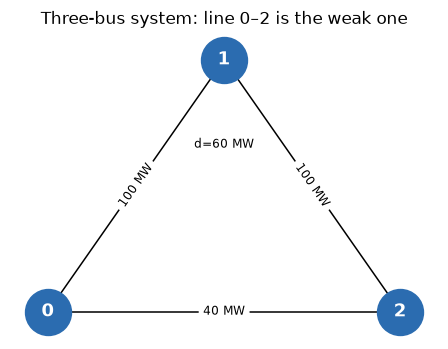

In [2]:
system = three_bus_system()
display(system.generator_table())
display(system.branch_table())
print(f"demand by bus: {system.demand},  total {system.total_demand:.0f} MW")

fig, ax = plt.subplots(figsize=(5.0, 3.6))
graph = nx.Graph()
for b in system.branches:
    graph.add_edge(b.from_bus, b.to_bus, label=f"{b.capacity:.0f} MW")
position = {0: (0, 0), 1: (1, 0.8), 2: (2, 0)}
nx.draw_networkx(graph, position, ax=ax, node_color=COLORS["feasible"],
                 node_size=900, font_color="white", font_weight="bold")
nx.draw_networkx_edge_labels(
    graph, position, ax=ax,
    edge_labels={(b.from_bus, b.to_bus): f"{b.capacity:.0f} MW" for b in system.branches},
    font_size=8,
)
for bus, (x, y) in position.items():
    ax.annotate(f"d={system.demand[bus]:.0f} MW", (x, y - 0.28), ha="center", fontsize=8)
ax.set_title("Three-bus system: line 0–2 is the weak one")
ax.axis("off")
plt.show()

## 2. The DC approximations, stated

The exact AC active-power flow from bus $i$ to bus $j$ is

$$P_{ij} = V_i^2 G_{ij} - V_i V_j \big(G_{ij}\cos\theta_{ij} + B_{ij}\sin\theta_{ij}\big).$$

Four assumptions turn that into one linear term:

| # | assumption | what it discards |
|---|---|---|
| 1 | $V_i \approx 1$ p.u. | voltage magnitude as a variable — and with it all voltage-limit constraints |
| 2 | $\theta_{ij}$ small, so $\sin\theta_{ij}\approx\theta_{ij}$, $\cos\theta_{ij}\approx1$ | accuracy under heavy loading, where angles are not small |
| 3 | $r_{ij} \ll x_{ij}$, so $G_{ij}\approx 0$ | **losses**, entirely |
| 4 | reactive power ignored | Q dispatch, and the coupling between Q and voltage |

What survives:

$$\boxed{P_{ij} = B_{ij}\,(\theta_i - \theta_j)}, \qquad B_{ij} = 1/x_{ij}$$

Assumption 3 is the one to watch. It is reasonable on a transmission network
where $r/x \approx 0.1$, and badly wrong on a distribution feeder — the
`case33bw` feeder in Tutorial 05 has a mean $r/x$ of **1.38**. Applying DC
power flow there is not conservative; it is meaningless.

### Nodal balance

$$\sum_{g \in \mathcal{G}_i} p_g \;-\; d_i \;=\; \sum_{j:(i,j)\in\mathcal{L}} P_{ij}$$

### The reference bus

Only angle *differences* matter, so one angle must be fixed:
$\theta_{ref} = 0$. Without it the model has a one-dimensional family of
optima and the solver will say so, usually unhelpfully.

## 3. DC-OPF in Pyomo

In [3]:
def dc_opf(system, *, line_capacity_override=None) -> pyo.ConcreteModel:
    """DC optimal power flow, written from the equations above."""
    m = pyo.ConcreteModel(name="DC-OPF")
    gens = {g.name: g for g in system.generators}
    branches = {b.name: b for b in system.branches}

    m.B = pyo.Set(initialize=system.buses)
    m.G = pyo.Set(initialize=list(gens))
    m.L = pyo.Set(initialize=list(branches))

    m.p = pyo.Var(m.G, bounds=lambda m, g: (gens[g].p_min, gens[g].p_max))
    m.theta = pyo.Var(m.B, domain=pyo.Reals, bounds=(-np.pi / 2, np.pi / 2))
    m.flow = pyo.Var(m.L, domain=pyo.Reals)

    m.reference = pyo.Constraint(expr=m.theta[system.reference_bus] == 0.0)

    @m.Constraint(m.L)
    def kvl(m, l):
        """Flow is proportional to the angle difference."""
        b = branches[l]
        return m.flow[l] == b.susceptance * (m.theta[b.from_bus] - m.theta[b.to_bus])

    @m.Constraint(m.L)
    def capacity_up(m, l):
        cap = (line_capacity_override or {}).get(l, branches[l].capacity)
        return m.flow[l] <= cap

    @m.Constraint(m.L)
    def capacity_down(m, l):
        cap = (line_capacity_override or {}).get(l, branches[l].capacity)
        return m.flow[l] >= -cap

    @m.Constraint(m.B)
    def nodal_balance(m, bus):
        """Injection at a bus equals the net flow leaving it. Its dual is the LMP."""
        generation = sum(m.p[g] for g in m.G if gens[g].bus == bus)
        outflow = sum(m.flow[l] for l in m.L if branches[l].from_bus == bus)
        inflow = sum(m.flow[l] for l in m.L if branches[l].to_bus == bus)
        return generation - system.demand.get(bus, 0.0) == outflow - inflow

    m.cost = pyo.Objective(
        expr=sum(gens[g].c1 * m.p[g] for g in m.G), sense=pyo.minimize
    )
    return m


model = dc_opf(system)
record = solve(model, "LP", duals=True)
print(record.summary())

dispatch = pd.DataFrame(
    {"output [MW]": {g: pyo.value(model.p[g]) for g in model.G}}
)
flows = pd.DataFrame(
    {
        "flow [MW]": {l: pyo.value(model.flow[l]) for l in model.L},
        "capacity [MW]": {b.name: b.capacity for b in system.branches},
    }
)
flows["loading"] = (flows["flow [MW]"].abs() / flows["capacity [MW]"])
display(dispatch.round(2))
display(flows.round(3))

LP    via appsi_highs  optimal      obj=   11,133.3333   0.02s  9 vars (0 binary), 13 cons, gap=0.000%


,output [MW]
G1_cheap,46.67
G2_mid,100.00
G3_peaker,63.33


,flow [MW],capacity [MW],loading
L_0_1,-13.333,100.0,0.133
L_1_2,26.667,100.0,0.267
L_0_2,40.000,40.0,1.000


## 4. One price became three

In Tutorial 01 there was a single $\lambda$. Here the balance is *per bus*, so
there is a dual per bus — a **locational marginal price**.

In [4]:
lmp = pd.Series(
    {bus: model.dual[model.nodal_balance[bus]] for bus in model.B}, name="LMP [EUR/MWh]"
)
display(lmp.round(3).to_frame())

binding = flows.index[flows["loading"] > 1 - 1e-6].tolist()
print(f"binding lines: {binding or 'none'}")
print(f"price spread : {lmp.max() - lmp.min():.2f} EUR/MWh")

if lmp.nunique() == 1:
    print("\nAll prices equal -> the network is not constraining anything.")
else:
    print("\nPrices differ ACROSS BUSES. The difference is the congestion rent:")
    print("power cannot get from the cheap bus to the expensive one, so the")
    print("expensive bus must be served locally at a higher marginal cost.")

,LMP [EUR/MWh]
0,20.000
1,51.111
2,90.000


binding lines: ['L_0_2']
price spread : 70.00 EUR/MWh

Prices differ ACROSS BUSES. The difference is the congestion rent:
power cannot get from the cheap bus to the expensive one, so the
expensive bus must be served locally at a higher marginal cost.


### The LMP decomposition

An LMP splits into an energy component and a congestion component:

$$\text{LMP}_i = \underbrace{\lambda}_{\text{energy}}
  \;+\; \underbrace{\sum_{l} \text{PTDF}_{l,i}\,\mu_l}_{\text{congestion}}$$

where $\mu_l$ is the dual of the line limit. With no congestion every $\mu_l$
is zero and all prices collapse to one number — which is Tutorial 01 again.

## 5. PTDFs

A **power transfer distribution factor** answers: if I inject 1 MW at bus $i$
and withdraw it at the reference, how much flows on line $l$?

$$\text{PTDF} = B_d\, A\, \big(A^\top B_d A\big)^{+}$$

with $A$ the branch–bus incidence matrix and $B_d$ the diagonal of
susceptances. The pseudo-inverse handles the reference bus.

PTDFs let you write DC-OPF **without angle variables** — flows become a linear
function of injections. That is why market and security models use them: you
can drop $\theta$ and keep only the constraints that bind.

In [5]:
def compute_ptdf(system) -> pd.DataFrame:
    """PTDF matrix, lines x buses, relative to the reference bus."""
    buses = system.buses
    branches = system.branches
    index = {bus: k for k, bus in enumerate(buses)}

    incidence = np.zeros((len(branches), len(buses)))
    susceptance = np.zeros(len(branches))
    for k, b in enumerate(branches):
        incidence[k, index[b.from_bus]] = 1.0
        incidence[k, index[b.to_bus]] = -1.0
        susceptance[k] = b.susceptance

    Bd = np.diag(susceptance)
    Bbus = incidence.T @ Bd @ incidence
    # Remove the reference row/column, invert, then pad back with zeros.
    keep = [k for bus, k in index.items() if bus != system.reference_bus]
    reduced = np.linalg.inv(Bbus[np.ix_(keep, keep)])
    full = np.zeros((len(buses), len(buses)))
    full[np.ix_(keep, keep)] = reduced

    return pd.DataFrame(
        Bd @ incidence @ full,
        index=[b.name for b in branches],
        columns=buses,
    )


ptdf = compute_ptdf(system)
display(ptdf.round(4))
print("Read a column: injecting 1 MW at that bus (and taking it out at the")
print(f"reference, bus {system.reference_bus}) moves this much on each line.")

,0,1,2
L_0_1,0.0,-0.6364,-0.1818
L_1_2,0.0,0.3636,-0.1818
L_0_2,0.0,-0.3636,-0.8182


Read a column: injecting 1 MW at that bus (and taking it out at the
reference, bus 0) moves this much on each line.


In [6]:
# Do the PTDF flows match the angle-based flows? They must.
injection = np.array([
    sum(pyo.value(model.p[g]) for g in model.G
        if {gg.name: gg for gg in system.generators}[g].bus == bus)
    - system.demand.get(bus, 0.0)
    for bus in system.buses
])
ptdf_flows = ptdf.to_numpy() @ injection
angle_flows = np.array([pyo.value(model.flow[l]) for l in ptdf.index])

check = pd.DataFrame(
    {"angle formulation": angle_flows, "PTDF formulation": ptdf_flows},
    index=ptdf.index,
)
check["difference"] = (check["angle formulation"] - check["PTDF formulation"]).abs()
display(check.round(8))
assert check["difference"].max() < 1e-8, "the two formulations disagree"
print(f"max difference: {check['difference'].max():.2e} MW — the same model, twice.")

,angle formulation,PTDF formulation,difference
L_0_1,-13.333333,-13.333333,0.0
L_1_2,26.666667,26.666667,0.0
L_0_2,40.000000,40.000000,0.0


max difference: 7.11e-15 MW — the same model, twice.


## 6. Exercises

---

### Exercise 3.1 — Relieve the congestion and watch the prices collapse

**Difficulty:** Basic

The weak line 0–2 is what separates the prices. Widen it and see what happens.

#### Your task

1. Solve the DC-OPF for a range of capacities on line `L_0_2`.
2. Record the total cost, each LMP, and the flow on that line.
3. Plot cost and price spread against capacity.

#### Expected result

Cost should fall as capacity rises, then flatten once the line stops binding.
The price spread should collapse to zero at exactly the same point.

#### Hint

`dc_opf(system, line_capacity_override={"L_0_2": value})`.

ERROR: evaluating object as numeric value: p[G1_cheap]
        (object: <class 'pyomo.core.base.var.VarData'>)
    No value for uninitialized VarData object p[G1_cheap]


ERROR: evaluating object as numeric value: cost
        (object: <class 'pyomo.core.base.objective.ScalarObjective'>)
    No value for uninitialized VarData object p[G1_cheap]


,total cost,flow L_0_2,LMP bus 0,LMP bus 1,LMP bus 2,price spread
capacity,,,,,,
20.0,NaN,NaN,NaN,NaN,NaN,NaN
30.0,11988.889,30.0,20.0,51.111,90.0,70.0
40.0,11133.333,40.0,20.0,51.111,90.0,70.0
50.0,10277.778,50.0,20.0,51.111,90.0,70.0
60.0,9422.222,60.0,20.0,51.111,90.0,70.0
70.0,8566.667,70.0,20.0,51.111,90.0,70.0
80.0,7711.111,80.0,20.0,51.111,90.0,70.0
90.0,6855.556,90.0,20.0,51.111,90.0,70.0


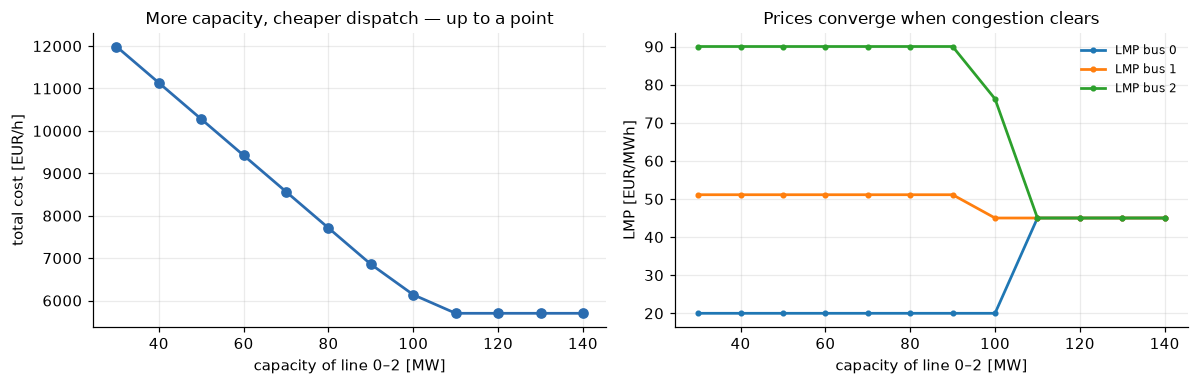

In [7]:
capacity_sweep = np.arange(20.0, 141.0, 10.0)

rows = []
for cap in capacity_sweep:
    m = dc_opf(system, line_capacity_override={"L_0_2": float(cap)})
    rec = solve(m, "LP", duals=True)
    if not rec.ok:
        rows.append({"capacity": cap, "total cost": np.nan})
        continue
    row = {"capacity": cap, "total cost": rec.objective,
           "flow L_0_2": pyo.value(m.flow["L_0_2"])}
    for bus in m.B:
        row[f"LMP bus {bus}"] = m.dual[m.nodal_balance[bus]]
    rows.append(row)

congestion = pd.DataFrame(rows).set_index("capacity")
lmp_columns = [c for c in congestion.columns if c.startswith("LMP")]
congestion["price spread"] = congestion[lmp_columns].max(axis=1) - congestion[lmp_columns].min(axis=1)
display(congestion.round(3).head(8))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(congestion.index, congestion["total cost"], "o-", color=COLORS["feasible"])
axes[0].set_xlabel("capacity of line 0–2 [MW]")
axes[0].set_ylabel("total cost [EUR/h]")
axes[0].set_title("More capacity, cheaper dispatch — up to a point")

for column in lmp_columns:
    axes[1].plot(congestion.index, congestion[column], "o-", ms=3, label=column)
axes[1].set_xlabel("capacity of line 0–2 [MW]")
axes[1].set_ylabel("LMP [EUR/MWh]")
axes[1].set_title("Prices converge when congestion clears")
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

In [8]:
assert congestion is not None, "build the `congestion` DataFrame first"
_valid = congestion.dropna(subset=["total cost"])
assert (_valid["total cost"].diff().dropna() <= 1e-6).all(), (
    "cost must be non-increasing in capacity — more freedom cannot cost more"
)
assert _valid["price spread"].iloc[-1] < _valid["price spread"].iloc[0] + 1e-9
print("Checks passed: cost is monotone in capacity and the spread shrinks.")

Checks passed: cost is monotone in capacity and the spread shrinks.


#### Interpretation

**Why are the nodal prices different?**

In [9]:
relieved = congestion[congestion["price spread"] < 1e-6]
print("ANSWER.")
print()
print("A price difference between two buses exists only when the network cannot")
print("move another MW between them. The LMP at a bus is the cost of serving one")
print("more MW OF DEMAND AT THAT BUS, and if the cheap generator's power cannot")
print("reach it, that cost is set locally.")
print()
if len(relieved):
    print(f"Here the spread vanishes once line 0-2 reaches "
          f"{relieved.index[0]:.0f} MW. Beyond that the line no longer binds, its")
    print("dual mu_l is zero, the congestion component of every LMP disappears, and")
    print("all three prices collapse to the single energy price lambda -- which is")
    print("Tutorial 01's one-price world recovered as a special case.")
print()
print("So congestion is not a separate phenomenon bolted onto pricing. It IS the")
print("dual of a binding transmission constraint, and it enters the price through")
print("the PTDF column of the line that binds.")

ANSWER.

A price difference between two buses exists only when the network cannot
move another MW between them. The LMP at a bus is the cost of serving one
more MW OF DEMAND AT THAT BUS, and if the cheap generator's power cannot
reach it, that cost is set locally.

Here the spread vanishes once line 0-2 reaches 110 MW. Beyond that the line no longer binds, its
dual mu_l is zero, the congestion component of every LMP disappears, and
all three prices collapse to the single energy price lambda -- which is
Tutorial 01's one-price world recovered as a special case.

So congestion is not a separate phenomenon bolted onto pricing. It IS the
dual of a binding transmission constraint, and it enters the price through
the PTDF column of the line that binds.


---

### Exercise 3.2 — Build the PTDF-based DC-OPF

**Difficulty:** Intermediate

The angle formulation carries one variable per bus. The PTDF formulation
carries none — flows are a linear function of injections.

#### Your task

1. Write `dc_opf_ptdf(system)` using the PTDF matrix and **no** $\theta$.
2. Solve it and check the dispatch, cost and LMPs match the angle model.
3. Compare the variable and constraint counts.

#### Think before coding

The nodal balance is gone too — what replaces it? (Hint: the *system* balance
must still hold, and it is now a single equation.)

#### Expected result

Identical objective and dispatch; a smaller model.

In [10]:
def dc_opf_ptdf(system) -> pyo.ConcreteModel:
    """DC-OPF with flows expressed through PTDFs instead of angles."""
    matrix = compute_ptdf(system)
    gens = {g.name: g for g in system.generators}
    branches = {b.name: b for b in system.branches}

    m = pyo.ConcreteModel(name="DC-OPF (PTDF)")
    m.B = pyo.Set(initialize=system.buses)
    m.G = pyo.Set(initialize=list(gens))
    m.L = pyo.Set(initialize=list(branches))
    m.p = pyo.Var(m.G, bounds=lambda m, g: (gens[g].p_min, gens[g].p_max))

    def injection(m, bus):
        return (
            sum(m.p[g] for g in m.G if gens[g].bus == bus)
            - system.demand.get(bus, 0.0)
        )

    # One system-wide balance replaces the per-bus balance: PTDFs already
    # encode where the power goes, but they cannot create or destroy it.
    m.system_balance = pyo.Constraint(
        expr=sum(injection(m, bus) for bus in m.B) == 0.0
    )

    @m.Constraint(m.L)
    def flow_up(m, l):
        return sum(matrix.loc[l, bus] * injection(m, bus) for bus in m.B) <= branches[l].capacity

    @m.Constraint(m.L)
    def flow_down(m, l):
        return sum(matrix.loc[l, bus] * injection(m, bus) for bus in m.B) >= -branches[l].capacity

    m.cost = pyo.Objective(expr=sum(gens[g].c1 * m.p[g] for g in m.G), sense=pyo.minimize)
    return m


ptdf_model = dc_opf_ptdf(system)
ptdf_record = solve(ptdf_model, "LP", duals=True)

side_by_side = pd.DataFrame(
    {
        "angle": {g: pyo.value(model.p[g]) for g in model.G},
        "PTDF": {g: pyo.value(ptdf_model.p[g]) for g in ptdf_model.G},
    }
)
display(side_by_side.round(4))
print(f"objective   angle {record.objective:,.4f}  |  PTDF {ptdf_record.objective:,.4f}")
print(f"variables   angle {record.n_variables:3d}     |  PTDF {ptdf_record.n_variables:3d}")
print(f"constraints angle {record.n_constraints:3d}     |  PTDF {ptdf_record.n_constraints:3d}")

,angle,PTDF
G1_cheap,46.6667,46.6667
G2_mid,100.0000,100.0000
G3_peaker,63.3333,63.3333


objective   angle 11,133.3333  |  PTDF 11,133.3333
variables   angle   9     |  PTDF   3
constraints angle  13     |  PTDF   7


In [11]:
assert ptdf_model is not None, "implement dc_opf_ptdf first"
assert abs(ptdf_record.objective - record.objective) < 1e-6, (
    f"the two formulations disagree: {ptdf_record.objective} vs {record.objective}"
)
for _g in model.G:
    assert abs(pyo.value(model.p[_g]) - pyo.value(ptdf_model.p[_g])) < 1e-6, (
        f"dispatch of {_g} differs between formulations"
    )
print("Checks passed: same optimum, same dispatch, fewer variables.")

Checks passed: same optimum, same dispatch, fewer variables.


#### Interpretation

**When is the PTDF formulation worth the trouble?**

In [12]:
print("ANSWER.")
print()
print("Two situations, and they are the ones that dominate real practice.")
print()
print("1. SECURITY-CONSTRAINED models. N-1 means re-checking every line under")
print("   every credible outage. With PTDFs an outage is a rank-one update of")
print("   the matrix (LODFs), so thousands of contingencies can be screened")
print("   without rebuilding a power flow each time.")
print()
print("2. MARKET models. Most lines never bind. PTDFs let you include only the")
print("   ones that might, because a flow limit is now a single linear")
print("   inequality in the injections rather than a chain through angles.")
print()
print("The catch: the PTDF matrix is DENSE and depends on the topology. Change a")
print("switch and it must be recomputed. The angle formulation is sparse and")
print("handles topology changes naturally, which is why solvers often prefer it")
print("for a single large solve. Neither is simply better.")

ANSWER.

Two situations, and they are the ones that dominate real practice.

1. SECURITY-CONSTRAINED models. N-1 means re-checking every line under
   every credible outage. With PTDFs an outage is a rank-one update of
   the matrix (LODFs), so thousands of contingencies can be screened
   without rebuilding a power flow each time.

2. MARKET models. Most lines never bind. PTDFs let you include only the
   ones that might, because a flow limit is now a single linear
   inequality in the injections rather than a chain through angles.

The catch: the PTDF matrix is DENSE and depends on the topology. Change a
switch and it must be recomputed. The angle formulation is sparse and
handles topology changes naturally, which is why solvers often prefer it
for a single large solve. Neither is simply better.


---

### Exercise 3.3 — How wrong is DC, and where does it stop being usable?

**Difficulty:** Advanced

DC power flow neglects losses and assumes flat voltages. The interesting
question is not whether it is wrong — it is — but **what actually limits it
first**.

#### Your task

1. Scale the demand up in steps, including past the point where the model
   stops having an answer.
2. At each level record the cost, the maximum angle difference, and the
   **termination condition**.
3. Find the loading at which the DC-OPF becomes infeasible, and say what that
   infeasibility is really telling you.
4. State what you would have to compute to answer "does the DC error change
   the dispatch?" properly — and why this notebook cannot answer it.

#### Think before coding

Write down, before you run anything, whether you expect the maximum angle
difference to grow or shrink as demand rises. Most people expect it to grow.

#### Expected result

Report what you observe rather than what you expected. Watch the termination
condition as well as the angles — one of them gives out well before the other,
and it may not be the one you predicted.

ERROR: evaluating object as numeric value: p[G1_cheap]
        (object: <class 'pyomo.core.base.var.VarData'>)
    No value for uninitialized VarData object p[G1_cheap]


ERROR: evaluating object as numeric value: cost
        (object: <class 'pyomo.core.base.objective.ScalarObjective'>)
    No value for uninitialized VarData object p[G1_cheap]


ERROR: evaluating object as numeric value: p[G1_cheap]
        (object: <class 'pyomo.core.base.var.VarData'>)
    No value for uninitialized VarData object p[G1_cheap]


ERROR: evaluating object as numeric value: cost
        (object: <class 'pyomo.core.base.objective.ScalarObjective'>)
    No value for uninitialized VarData object p[G1_cheap]


,cost,max |dtheta| [deg],sin(x)/x,status
scale,,,,
0.6,5066.6667,5.3476,0.9985,optimal
0.8,8100.0000,4.5837,0.9989,optimal
1.0,11133.3333,3.8197,0.9993,optimal
1.2,NaN,NaN,NaN,infeasible
1.4,NaN,NaN,NaN,infeasible



feasible up to scale 1.0; infeasible from scale 1.2


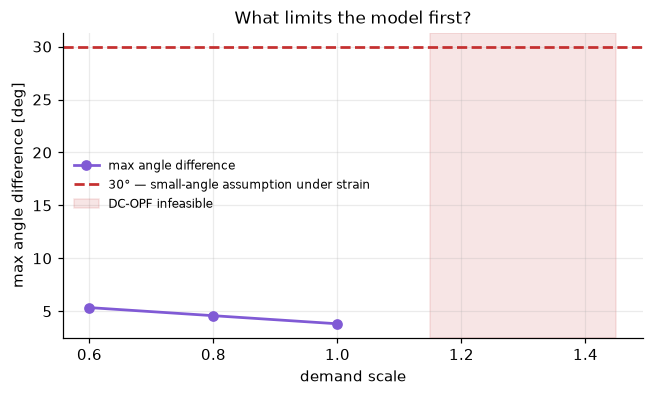

In [13]:
scale_sweep = [0.6, 0.8, 1.0, 1.2, 1.4]

rows = []
branches = {b.name: b for b in system.branches}
for scale in scale_sweep:
    scaled_system = three_bus_system(scale=scale)
    m = dc_opf(scaled_system)
    rec = solve(m, "LP", duals=True)
    if not rec.ok:
        rows.append({"scale": scale, "cost": np.nan, "max |dtheta| [deg]": np.nan,
                     "sin(x)/x": np.nan, "status": rec.termination})
        continue
    differences = [
        abs(pyo.value(m.theta[b.from_bus]) - pyo.value(m.theta[b.to_bus]))
        for b in scaled_system.branches
    ]
    worst = max(differences)
    rows.append({
        "scale": scale, "cost": rec.objective,
        "max |dtheta| [deg]": np.degrees(worst),
        "sin(x)/x": np.sin(worst) / worst if worst > 1e-9 else 1.0,
        "status": rec.termination,
    })

dc_strain = pd.DataFrame(rows).set_index("scale")
display(dc_strain.round(4))

feasible = dc_strain[dc_strain["status"] == "optimal"]
infeasible = dc_strain[dc_strain["status"] != "optimal"]
print(f"\nfeasible up to scale {feasible.index.max():.1f}; "
      f"infeasible from scale {infeasible.index.min():.1f}"
      if len(infeasible) else "\nfeasible at every scale tested")

fig, ax = plt.subplots(figsize=(6.8, 3.6))
ax.plot(feasible.index, feasible["max |dtheta| [deg]"], "o-", color=COLORS["accent"],
        label="max angle difference")
ax.axhline(30, ls="--", color=COLORS["infeasible"],
           label="30° — small-angle assumption under strain")
if len(infeasible):
    ax.axvspan(infeasible.index.min() - 0.05, dc_strain.index.max() + 0.05,
               color=COLORS["infeasible"], alpha=0.12, label="DC-OPF infeasible")
ax.set_xlabel("demand scale")
ax.set_ylabel("max angle difference [deg]")
ax.set_title("What limits the model first?")
ax.legend(fontsize=8)
plt.show()

In [14]:
assert dc_strain is not None, "build the `dc_strain` table first"
_v = dc_strain[dc_strain["status"] == "optimal"]
assert len(_v) >= 2, "at least two loadings should be solvable"
assert (_v["sin(x)/x"] <= 1.0 + 1e-9).all(), "sin(x)/x cannot exceed 1"
assert (_v["cost"].diff().dropna() >= -1e-6).all(), "serving more load cannot cost less"
# Deliberately NOT asserting that angles grow: on this system they do not, and
# a check that encodes the expectation rather than the measurement is how a
# wrong belief gets frozen into a test suite.
_trend = "grow" if _v["max |dtheta| [deg]"].diff().dropna().mean() > 0 else "shrink"
print(f"Checks passed over the {len(_v)} feasible loadings.")
print(f"Observed: angle differences {_trend} with loading "
      f"({_v['max |dtheta| [deg]'].iloc[0]:.2f} -> "
      f"{_v['max |dtheta| [deg]'].iloc[-1]:.2f} deg).")

Checks passed over the 3 feasible loadings.
Observed: angle differences shrink with loading (5.35 -> 3.82 deg).


#### Interpretation

**Is "linear means inaccurate" a fair summary?**

In [15]:
solved = dc_strain[dc_strain["status"] == "optimal"]
worst_ratio = solved["sin(x)/x"].min()
print("ANSWER. No — it confuses two different things. And on THIS system,")
print("something else goes wrong long before accuracy does.")
print()
print("Over the loadings that solve at all, the small-angle error reaches only")
print(f"{(1 - worst_ratio):.4%}: sin(theta) is that much below theta, with a")
print(f"largest angle difference of {solved['max |dtheta| [deg]'].max():.2f} deg. The")
print("small-angle assumption is in no trouble whatsoever here.")
print()
print("AND THE ANGLES GO THE WRONG WAY. They SHRINK as demand rises:")
print(f"  {solved['max |dtheta| [deg]'].iloc[0]:.2f} deg at scale "
      f"{solved.index[0]:.1f}  ->  "
      f"{solved['max |dtheta| [deg]'].iloc[-1]:.2f} deg at scale {solved.index[-1]:.1f}")
print()
print("The reason is dispatch, not physics. At light load the cheap unit at bus 0")
print("serves almost everything, so a lot of power has to TRAVEL and the angles")
print("across the network are large. As load grows, the cheap unit saturates and")
print("the expensive LOCAL units at buses 1 and 2 pick up the difference -- so")
print("less power travels and the angle differences fall.")
print()
print("The lesson: the small-angle assumption strains with POWER TRANSPORT, not")
print("with demand. Those two usually move together, and on this system they move")
print("in opposite directions. An intuition about when an approximation degrades")
print("is a hypothesis, and this one was wrong.")
print()
unsolved = dc_strain[dc_strain["status"] != "optimal"]
if len(unsolved):
    print(f"What DOES happen is that the model becomes INFEASIBLE at scale "
          f"{unsolved.index.min():.1f}.")
    print("That is not an approximation error. It is the 40 MW line telling us that")
    print("bus 2 cannot be served at that loading, whatever formulation we use. The")
    print("binding limit is physical, not numerical -- and a student who went")
    print("looking for accuracy problems would have missed it.")
print()
print("But 'inaccurate' is the wrong axis. The right questions are:")
print()
print("  1. Does the error change the DECISION? A 3% flow error that never moves")
print("     the binding constraint changes no dispatch and costs nothing.")
print("  2. Is the model an APPROXIMATION or a RELAXATION? DC-OPF is an")
print("     approximation: it solves DIFFERENT equations. So its optimum is not")
print("     a bound on the AC optimum in either direction. That is a much")
print("     sharper statement than 'inaccurate', and Tutorial 05 makes it")
print("     precise.")
print()
print("This notebook CANNOT answer question 1, and that limitation is the point.")
print("Comparing against the truth needs AC equations, which is Tutorial 04. What")
print("we can see here is only the internal strain on the assumptions -- a")
print("necessary check, not a sufficient one.")
print()
print("One place the approximation is not merely strained but meaningless: a")
print("distribution feeder with r/x > 1, where assumption 3 discards the")
print("dominant term. Tutorial 05's feeder has mean r/x = 1.38.")

ANSWER. No — it confuses two different things. And on THIS system,
something else goes wrong long before accuracy does.

Over the loadings that solve at all, the small-angle error reaches only
0.1451%: sin(theta) is that much below theta, with a
largest angle difference of 5.35 deg. The
small-angle assumption is in no trouble whatsoever here.

AND THE ANGLES GO THE WRONG WAY. They SHRINK as demand rises:
  5.35 deg at scale 0.6  ->  3.82 deg at scale 1.0

The reason is dispatch, not physics. At light load the cheap unit at bus 0
serves almost everything, so a lot of power has to TRAVEL and the angles
across the network are large. As load grows, the cheap unit saturates and
the expensive LOCAL units at buses 1 and 2 pick up the difference -- so
less power travels and the angle differences fall.

The lesson: the small-angle assumption strains with POWER TRANSPORT, not
with demand. Those two usually move together, and on this system they move
in opposite directions. An intuition about whe

## 7. Key takeaways

1. **DC power flow is four assumptions**, and each one discards something
   nameable. Losses and voltage limits are gone entirely.
2. **One balance per bus gives one price per bus.** LMPs are the duals of the
   nodal balance constraints.
3. **Congestion is the dual of a binding line limit.** Relieve the line and the
   prices collapse to a single energy price.
4. **PTDF and angle formulations are the same model**, verified to $10^{-8}$
   here. They differ in sparsity and in how they handle topology change.
5. **DC-OPF is an approximation, not a relaxation** — so it gives no bound.
   Tutorial 05 explains why that distinction matters more than accuracy.

## Further reading

- Stott, Jardim & Alsaç, "DC power flow revisited", *IEEE Trans. Power Syst.*
  24(3), 2009 — the honest account of what DC does and does not do.
- Schweppe et al., *Spot Pricing of Electricity*, Kluwer 1988 — the origin of
  locational marginal pricing.
- Litvinov et al., "Marginal loss modeling in LMP calculation", *IEEE Trans.
  Power Syst.* 19(2), 2004.

## Next

Tutorial 04 puts the discarded physics back: voltage magnitudes, reactive
power and losses. The model stops being linear, stops being convex, and
"optimal" stops meaning what it meant here.